In [1]:
#라이브러리
import os
import json
import pandas as pd
from collections import Counter

In [2]:
#기본 경로 설정
BASE_PATH = "/gpfs/data/oermannlab/gaifl/users/yl14814/SLM_hybrid_project"

models = ["llama31", "mistral7b", "qwen2_7b"]
methods = ["zeroshot", "cot", "fewshot"]

In [3]:
#Accuracy계산 함수
def compute_accuracy(path):
    if not os.path.exists(path):
        print(f"❌ Missing: {path}")
        return None

    with open(path, "r") as f:
        data = json.load(f)

    correct = sum(x["correct"] for x in data)
    total = len(data)

    return correct / total

In [4]:
#전체 Accuracy table 생성
results = []

for model in models:
    for method in methods:

        file_path = f"{BASE_PATH}/03_results/baselines/{model}/MedQA/MedQA_{method}_chat_full.json"

        acc = compute_accuracy(file_path)

        results.append({
            "Model": model,
            "Method": method,
            "Accuracy": acc
        })

df = pd.DataFrame(results)

pivot_df = df.pivot(index="Model", columns="Method", values="Accuracy")

print("\n=== Accuracy Table ===")
print(pivot_df)


=== Accuracy Table ===
Method          cot   fewshot  zeroshot
Model                                  
llama31    0.401414  0.604085  0.609584
mistral7b  0.392773  0.494108  0.515318
qwen2_7b   0.364493  0.493323  0.516889


In [5]:
#CSV 저장
save_csv = f"{BASE_PATH}/03_results/MedQA_accuracy_summary.csv"

pivot_df.to_csv(save_csv)

print("Saved to:", save_csv)

Saved to: /gpfs/data/oermannlab/gaifl/users/yl14814/SLM_hybrid_project/03_results/MedQA_accuracy_summary.csv


In [6]:
#상세분석함수
def analyze_file(path):

    if not os.path.exists(path):
        return None

    with open(path, "r") as f:
        data = json.load(f)

    preds = [x["prediction"] for x in data]

    invalid_count = preds.count("INVALID")

    return {
        "accuracy": sum(x["correct"] for x in data) / len(data),
        "invalid_ratio": invalid_count / len(data),
        "distribution": Counter(preds)
    }

In [7]:
#detailed analysis 진행
analysis_results = []

for model in models:
    for method in methods:

        path = f"{BASE_PATH}/03_results/baselines/{model}/MedQA/MedQA_{method}_chat_full.json"

        result = analyze_file(path)

        if result:
            analysis_results.append({
                "Model": model,
                "Method": method,
                "Accuracy": result["accuracy"],
                "Invalid Ratio": result["invalid_ratio"]
            })

analysis_df = pd.DataFrame(analysis_results)

print("\n=== Detailed Analysis ===")
print(analysis_df)


=== Detailed Analysis ===
       Model    Method  Accuracy  Invalid Ratio
0    llama31  zeroshot  0.609584       0.008641
1    llama31       cot  0.401414       0.016496
2    llama31   fewshot  0.604085       0.000000
3  mistral7b  zeroshot  0.515318       0.004713
4  mistral7b       cot  0.392773       0.034564
5  mistral7b   fewshot  0.494108       0.000786
6   qwen2_7b  zeroshot  0.516889       0.052632
7   qwen2_7b       cot  0.364493       0.029065
8   qwen2_7b   fewshot  0.493323       0.000000


In [8]:
#prediction 분포 보기
analysis_results = []

for model in models:
    for method in methods:

        path = f"{BASE_PATH}/03_results/baselines/{model}/MedQA/MedQA_{method}_chat_full.json"

        result = analyze_file(path)

        if result:
            analysis_results.append({
                "Model": model,
                "Method": method,
                "Accuracy": result["accuracy"],
                "Invalid Ratio": result["invalid_ratio"]
            })

analysis_df = pd.DataFrame(analysis_results)

print("\n=== Detailed Analysis ===")
print(analysis_df)


=== Detailed Analysis ===
       Model    Method  Accuracy  Invalid Ratio
0    llama31  zeroshot  0.609584       0.008641
1    llama31       cot  0.401414       0.016496
2    llama31   fewshot  0.604085       0.000000
3  mistral7b  zeroshot  0.515318       0.004713
4  mistral7b       cot  0.392773       0.034564
5  mistral7b   fewshot  0.494108       0.000786
6   qwen2_7b  zeroshot  0.516889       0.052632
7   qwen2_7b       cot  0.364493       0.029065
8   qwen2_7b   fewshot  0.493323       0.000000


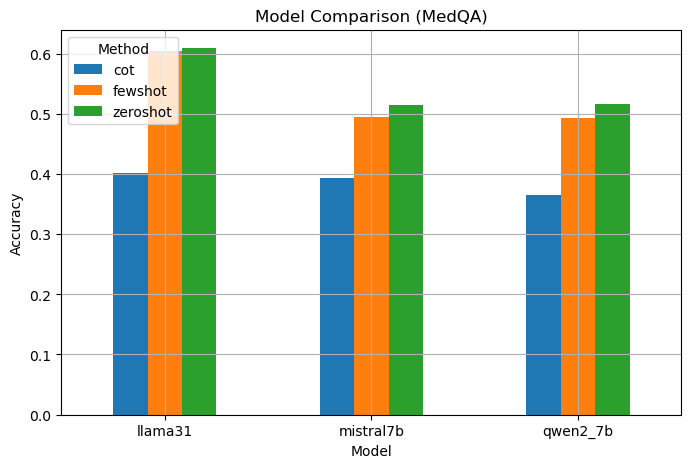

In [9]:
#셀 시각화
import matplotlib.pyplot as plt

pivot_df.plot(kind="bar", figsize=(8,5))

plt.title("Model Comparison (MedQA)")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.grid()

plt.show()